<div class='alert alert-block alert-info"'>
<h1> Simulation study :</h1>

<h4> Variable selection and estimation in a joint model of logitic longitudinal data and survival data </h4>
</div>

In [1]:
import pickle
import gzip

import jax.numpy as jnp

from sdg4varselect.logistic import Logistic_JM, get_params_star

import sdg4varselect.plot as sdgplt
sdgplt.FIGSIZE = 15

def read(n, p, s):
    model = Logistic_JM(N=n, J=5, DIM_HD=p)
    filename = f"test_s{s}_N{model.N}_P{model.DIM_HD}_J{model.J}"

    R = pickle.load(gzip.open(f"files/{filename}.pkl.gz", "rb"))
    print(f"{filename} LOADED")
    return R

def read_multi_files(N, P, S= 0):
    if len(N) == 1  and len(P) == 1:
        results = read(50, 8, 2)
        N = results["N"]
        P = results["P"]
        lbd_set = results["lbd_set"]
        results = results["res"]

        censoring_rate = jnp.array([[r.censoring_rate for r in res] for res in results]).mean(axis = 1)
        scenarios_labels  = [f"C = {c*100:.0f}%" for c in censoring_rate]
        results = [[r.estim_res for r in res ]for res in results]

    elif len(P) == 1:
        results = [read(n, P[0], 0) for n in N]
        N = [resN["N"] for resN in results]
        P = results[0]["P"]
        lbd_set = results[0]["lbd_set"]
        results = [[resnrun for resnrun in resN["res"][0]] for resN in results]

        scenarios_labels  = [f"N = {n}" for n in N]
    elif len(N) == 1:                
        results = [read(N[0], p, 0) for p in P]
        N = results[0]["N"]
        P = [resP["P"] for resP in results]
        lbd_set = results[0]["lbd_set"]
        results = [[resnrun for resnrun in resP["res"][0]] for resP in results]

        scenarios_labels  = [f"P = {p}" for p in P]
    return results, lbd_set, N, P, scenarios_labels

        
        
    #     [[ for n in N] for p in P]

    # lbd_set = results[0][0]["lbd_set"]

    # N = [[r["N"] for r in res] for res in results]
    # P = [[r["P"] for r in res] for res in results]
    # results = [[r["res"] for r in res] for res in results]
    # print(f"shape(results) = ({len(results)}, {len(results[0])})")
    # if len(results[0]) == 1:
    #     results = [results[i][0] for i in range(len(results))]
    #     N = [N[i][0] for i in range(len(results))]
    #     P = [P[i][0] for i in range(len(results))]

    # if len(results) == 1:
    #     results = results[0]
    #     N = N[0]
    #     P = P[0]

    # scenarios_labels = []
    # if not (isinstance(P, list) or isinstance(N, list)): #censoring scenerios
    #     censoring_rate = jnp.array([[r.censoring_rate for r in res] for res in results]).mean(axis = 1)
    #     scenarios_labels  = [f"C = {c*100:.0f}%" for c in censoring_rate]
    #     results = [[r.estim_res for r in res ]for res in results] 
    # else:
    #     scenarios_labels = [f"N = {n}" for n in N] if len(P) == 1 else [f"P = {p}" for p in P]
    # return results, lbd_set, N, P, scenarios_labels

In this section, we propose to study the performance of the procedure we have just presented. First of all, we want to show numerically the consistency of the estimator (ref{eq:penalized_estimator}) by studying 4 scenarios, varying the number of individuals observed. Then we'll demonstrate the method's ability to select variables by varying the number of covariates in the initial model. And finally with 3 relevant scenarios we will study the effect of censorship on the estimation procedure. This simulation study is conducted in the case of joint modeling for longitudinal logistic data, and a result for the pharmakokinetik model will also be presented in the end. In each scenario we generate independent data set and each time we fit the ref{eq:joint} model using the ref{algo:SPG-fim} routine described above (ref{algo:metho}).

Before anything else, to compare the next results of different scenarios, we look at the estimation error. We consider separately the relative root mean square errors $rrmse$ of the high dimensional parameters $\beta \in \mathbb R^p$ and of the low dimensional parameters, denotes by $\nu \in \mathbb R^d$ :
        
$$rrmse (\beta)  = \sqrt{\frac {||\beta -\hat\beta||^2}{p ||\beta||^2} } ~;~ rrmse (\nu)  = \sqrt{\frac 1d \sum_{i=1}^d  \frac {(\nu_i -\hat\nu_i)^2}{\nu_i^2 } }$$

# Logistic Joint-Model Specification

We first consider the joint model defined \ref{eq:joint} with the classical logistic function for the non-linear mixed effects model, defined by :

$$
    m: t \mapsto \dfrac{Z_1}{1 + \exp\left(\dfrac{Z_2-t}{Z_3}\right)},
$$

Where $Z_1$ represents the asymptotical maximum value of the curve, $Z_2$ represents the value of the sigmoid's midpoint, and $Z_3$ represents the logistic growth rate. 
We model for each individual $i$ the corresponding individual parameter $Z_i\in \mathbb R^3$ through a Gaussian random variable with expectation $\mu  \in \mathbb R^3$ and a diagonal variance $\Gamma=diag(\gamma_1^2,\gamma_2^2,0)$ meaning that the third parameter $\mu_3$ is modeled as a fixed effect. 

We consider a fixed Weibull baseline defined as $h_{a,b}(t)= b a^{-b} t^{b-1}$, where $a=80$ and $b=35$ are fixed (i.e. not estimated) in the simulation study. We focus in this simulation study on the selection of variables and on the inference  of the parameters of the mixed-effect model as well as  $\alpha$ the multiplicative parameter of the Cox model.

## Simulation setup

We generated 20 data set according to the joint model presented previously in Equation ref{eq:joint}. For each different value of $p$, we  choose the vector $\beta$ such that the first four components are equal to $(-2,-1,1,2)$ and the rest are equal to zero. Additionally, we generate the matrix of covariates $U$ with $N$ rows and $p$ columns, following a uniform distribution $U_{i,l} \sim \mathcal U([-1,1]) ; ~\forall i \in { 1, ..., N}, l\in{1,..., p}$. Afterwards, we renormalize all the matrix columns to obtain centered data. All the parameter values are detailed in the table ref{tab:truevalues} below.

In [2]:
params_star = get_params_star(DIM_HD=6)
print(str(params_star).replace(", dtype=float64),", "),\n\t  "))
params_star = jnp.hstack(get_params_star(200))

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


Parameters(mu1=Array(0.3),
	   mu2=Array(90.),
	   mu3=Array(7.5),
	   gamma2_1=Array(0.0025),
	   gamma2_2=Array(20.),
	   sigma2=Array(0.001),
	   alpha=Array(11.11),
	   beta=Array([-2., -3.,  3.,  2.,  0.,  0.], dtype=float64))


## Consistancy of $\hat\theta_{MLE}$

In this part, we aim to show the numerical consistance of the proposed estimator ref{eq:penalized_estimator}, thus we focus on four scenarios where the number of individuals observed is increasing : $N\in\{50,100,200,300\}$ when the number of covariates $p = 200$ and the number of longitudinal observations $J = 5$ are fixed. 

In [3]:
results, lbd_set, _,_, scenarios_labels = read_multi_files(N = (50, 100, 200, 300), P = (200,), S = 0)

model = Logistic_JM(N=100, J=5, DIM_HD=200)

params_star = jnp.hstack(get_params_star(model.DIM_HD))
params_names = model.params_names

test_s0_N50_P200_J5 LOADED
test_s0_N100_P200_J5 LOADED
test_s0_N200_P200_J5 LOADED
test_s0_N300_P200_J5 LOADED


The following graphe show the estimations for each parameter for the four scenarios

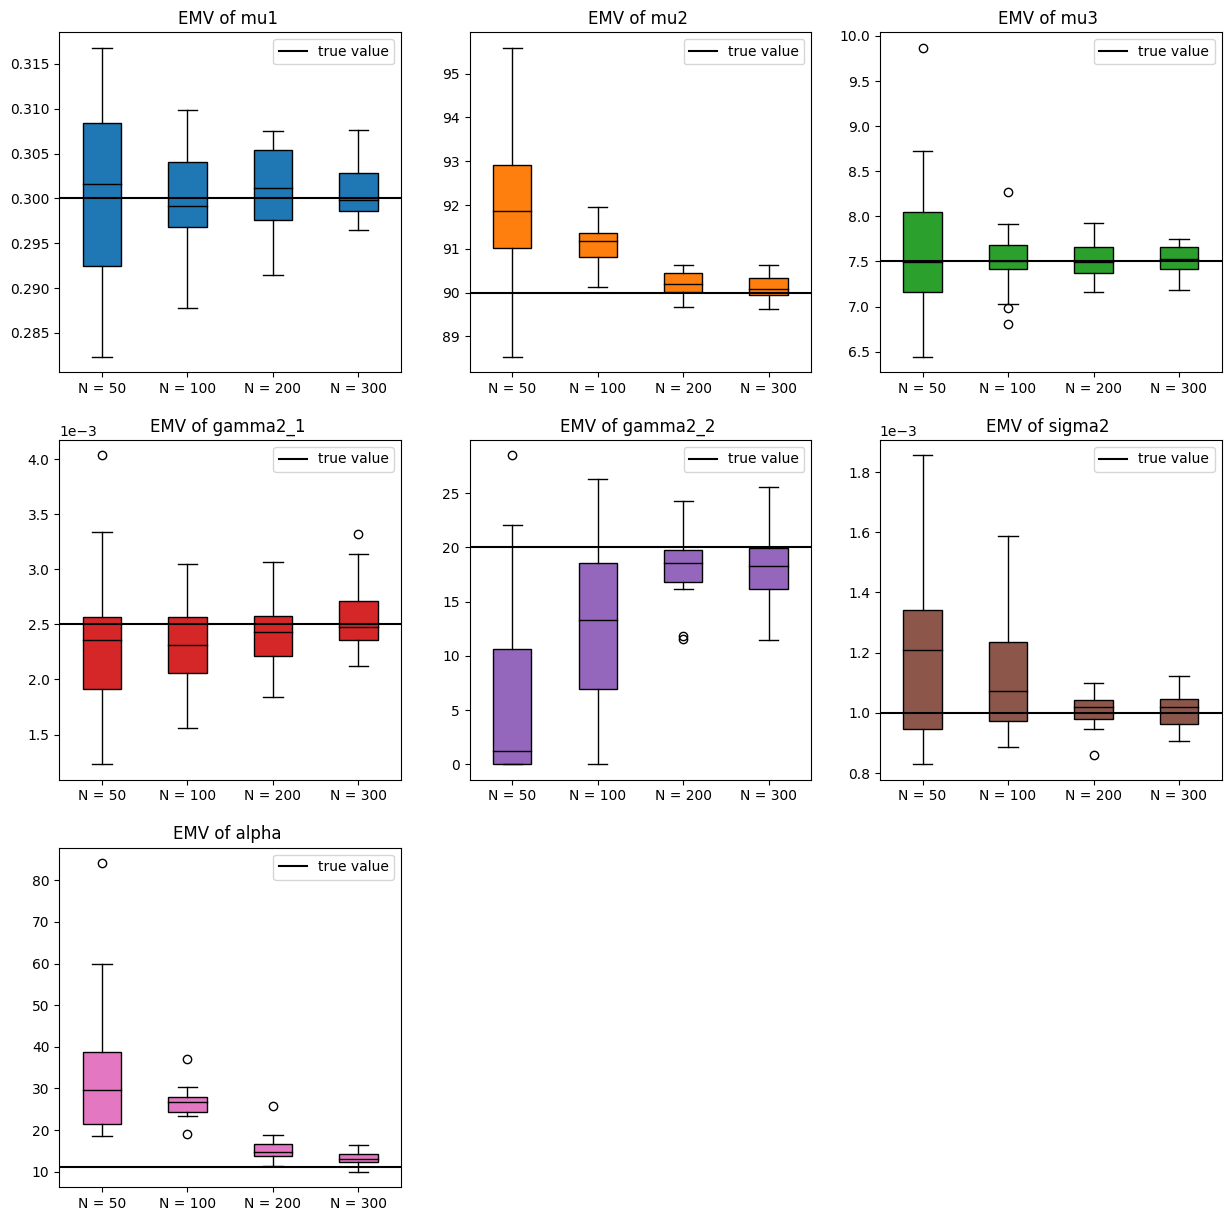

In [4]:
theta = jnp.array([[r.theta for r in res] for res in results])

fig = sdgplt.figure()
for i in range(7):
    ax = fig.add_subplot(3, 3, 1 + i)
    ax.ticklabel_format(style="sci", scilimits=(-3, 3))
    bp = ax.boxplot(theta[:, :, i], patch_artist=True, labels=scenarios_labels)

    for patch in bp["boxes"]:
        patch.set(facecolor=f"C{i}")

    for median in bp["medians"]:
        median.set_color("black")

    ax.axhline(y=params_star[i], color="k", label="true value")

    ax.legend()
    ax.set_title(f"EMV of {params_names[i]} ")

Text(0.5, 1.0, 'Estimation of the remaining zero components of beta')

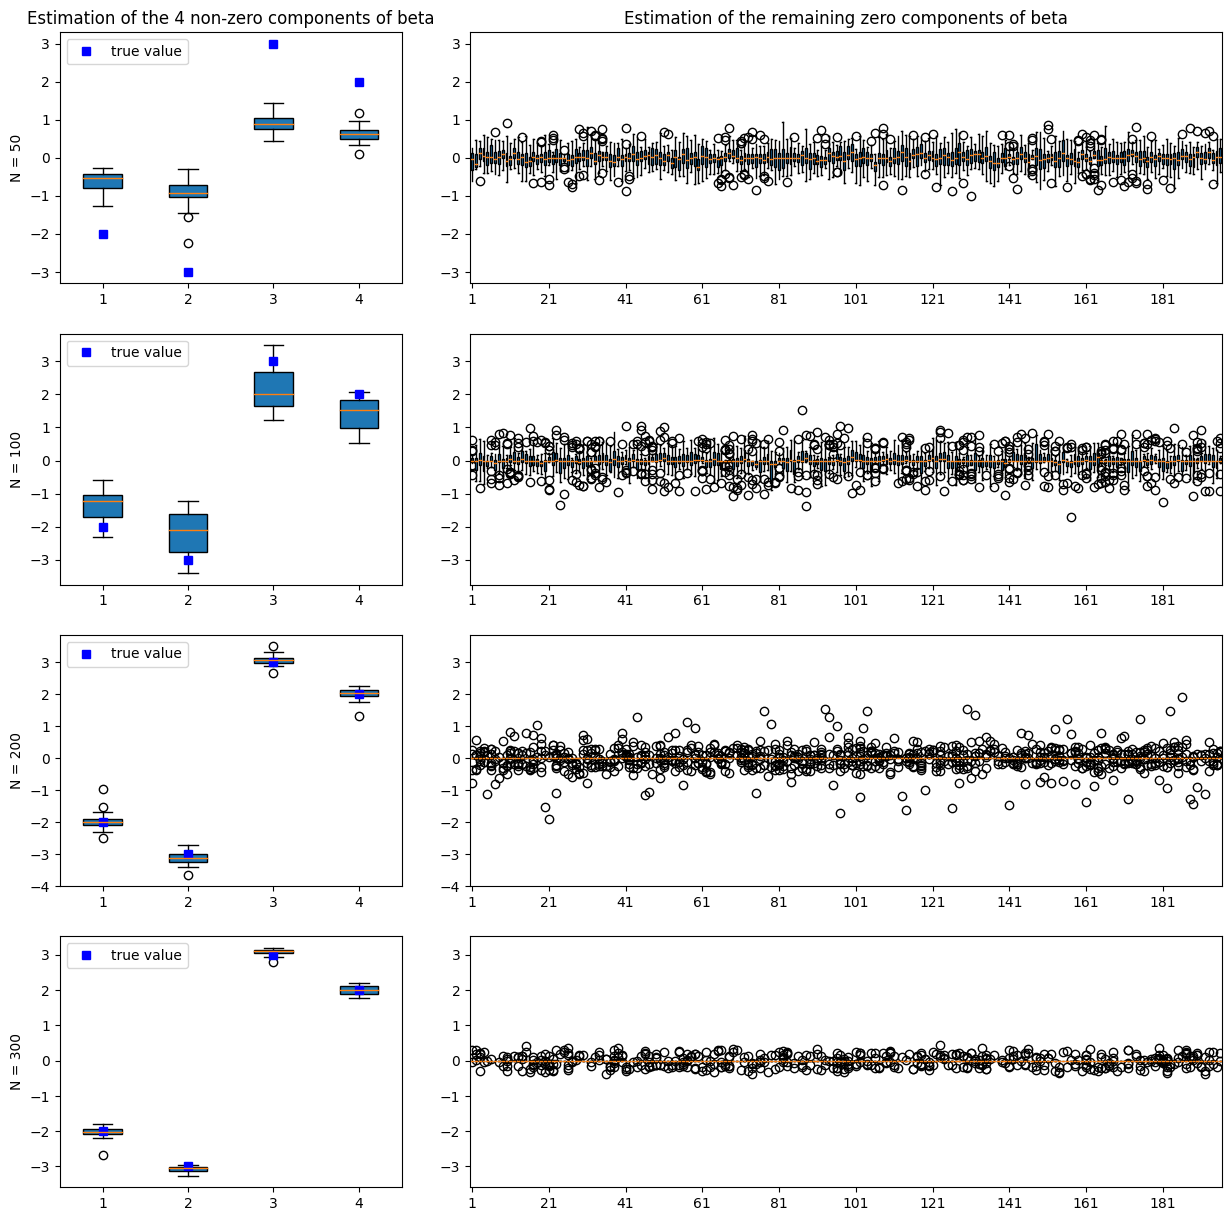

In [5]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

params_star_HD = params_star[7:]
theta = [jnp.array([r.theta[model.DIM_LD :] for r in res]) for res in results]

G = GridSpec(len(results), 3)
fig = sdgplt.figure()

xticks = jnp.arange(0, model.DIM_HD) + 1
for i in range(len(results)):
    ax = plt.subplot(G[i, 0])
    bp = ax.boxplot(theta[i][:, :4].T, patch_artist=True)
    ax.plot(xticks[:4], params_star_HD[:4], "bs", label="true value")
    ax.legend()
    ax.set_ylabel(scenarios_labels[i])
    # == == == == #
    ax = plt.subplot(G[i, 1:], sharey = ax)
    bp = ax.boxplot(theta[i][:, 4:].T, patch_artist=True)
    
    xticks_nonzero = jnp.arange(1, model.DIM_HD, step = model.DIM_HD//10)
    ax.set_xticks(xticks_nonzero,xticks_nonzero)

ax = plt.subplot(G[0, 0])
ax.set_title(f"Estimation of the 4 non-zero components of beta")
ax = plt.subplot(G[0, 1:], sharey = ax)
ax.set_title(f"Estimation of the remaining zero components of beta")

## Variable selection capacity

We now want to demonstrate our method's ability to perform variable selection. We define the following scenarios, with $N=100$ and $J=5$ fixed, we set the number of covariates increasing $P\in\{50,100,200,250,300,350,600, 800, 1000\}$.

In [6]:
P=(50, 100, 250, 300, 350, 600, 800, 1000)
results, lbd_set, _,_, scenarios_labels = read_multi_files(N=(100,), P=P)

model = Logistic_JM(N=100, J=5, DIM_HD=max(P))

params_star = jnp.hstack(get_params_star(model.DIM_HD))
params_names = model.params_names

test_s0_N100_P50_J5 LOADED
test_s0_N100_P100_J5 LOADED
test_s0_N100_P250_J5 LOADED
test_s0_N100_P300_J5 LOADED
test_s0_N100_P350_J5 LOADED
test_s0_N100_P600_J5 LOADED
test_s0_N100_P800_J5 LOADED
test_s0_N100_P1000_J5 LOADED


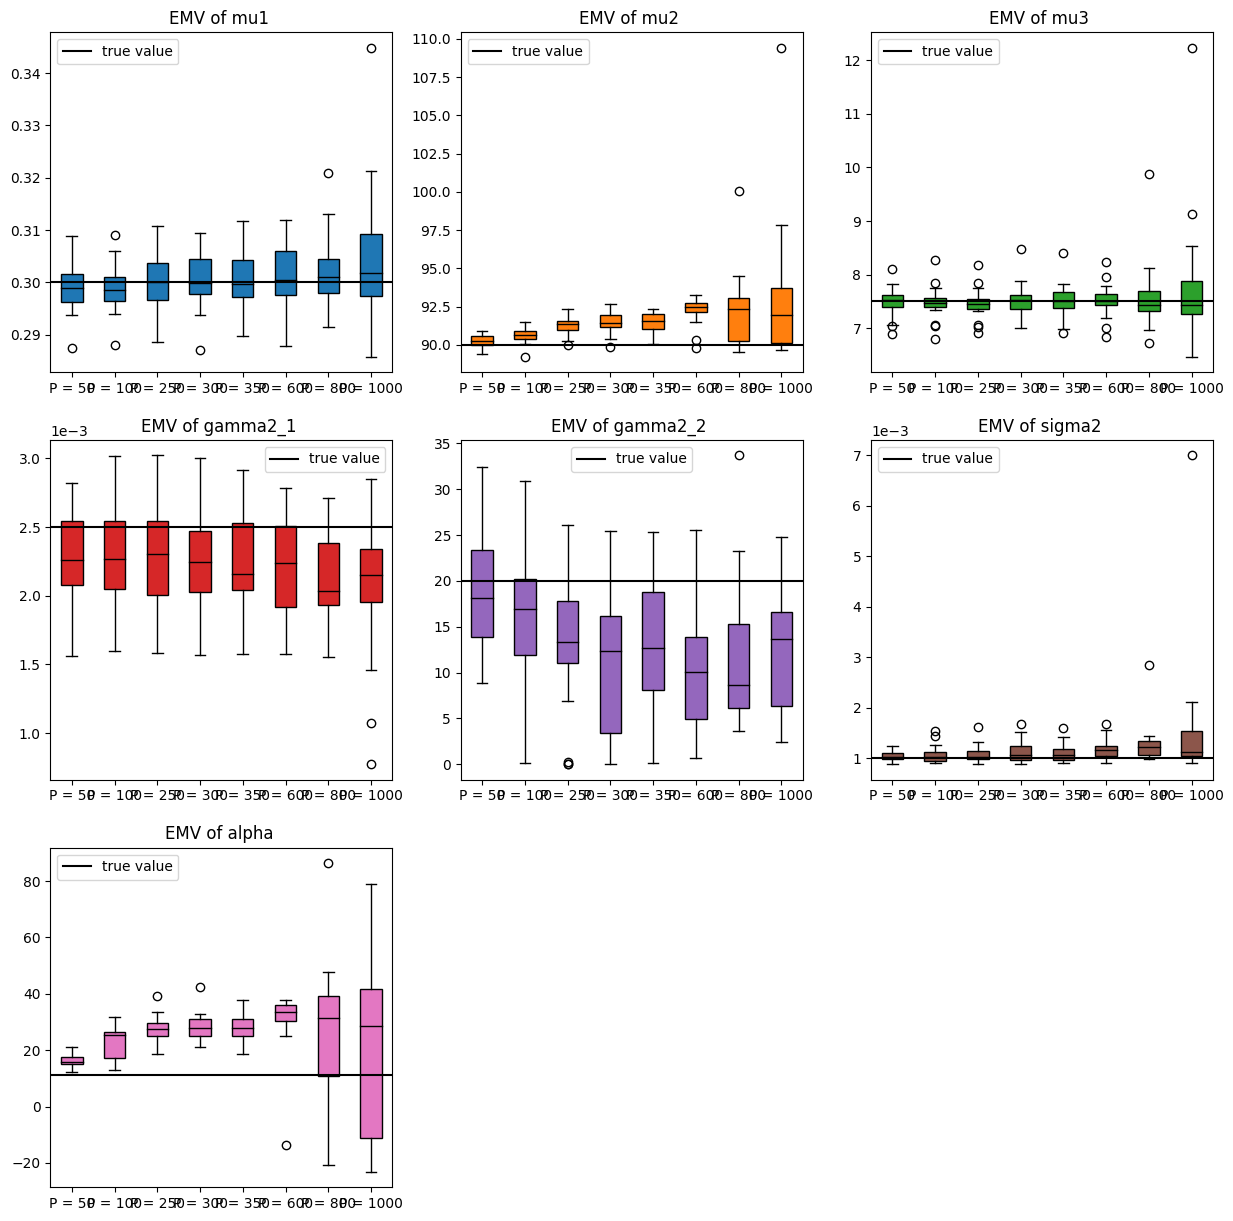

In [7]:
theta = jnp.array([[r.theta[: model.DIM_LD] for r in res] for res in results])

fig = sdgplt.figure()
for i in range(7):
    ax = fig.add_subplot(3, 3, 1 + i)
    ax.ticklabel_format(style="sci", scilimits=(-3, 3))
    bp = ax.boxplot(theta[:, :, i], patch_artist=True, labels=scenarios_labels)

    for patch in bp["boxes"]:
        patch.set(facecolor=f"C{i}")

    for median in bp["medians"]:
        median.set_color("black")

    ax.axhline(y=params_star[i], color="k", label="true value")

    ax.legend()
    ax.set_title(f"EMV of {params_names[i]} ")

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

params_star_HD = params_star[7:]
theta = [jnp.array([r.theta[model.DIM_LD :] for r in res]) for res in results]

G = GridSpec(len(results), 3)
fig = sdgplt.figure()

xticks = jnp.arange(0, max(P)) + 1
for i in range(len(results)):
    ax = plt.subplot(G[i, 0])
    bp = ax.boxplot(theta[i][:, :4].T, patch_artist=True)
    ax.plot(xticks[:4], params_star_HD[:4], "bs", label="true value")
    ax.legend()
    ax.set_ylabel(scenarios_labels[i])
    # == == == == #
    ax = plt.subplot(G[i, 1:], sharey = ax)
    bp = ax.boxplot(theta[i][:, 4:].T, patch_artist=True)
    
    xticks_nonzero = jnp.arange(1, (P[i]-4), step = (P[i]-4)//20)
    ax.set_xticks(xticks_nonzero,xticks_nonzero)

ax = plt.subplot(G[0, 0])
ax.set_title(f"Estimation of the 4 non-zero components of beta")
ax = plt.subplot(G[0, 1:], sharey = ax)
ax.set_title(f"Estimation of the remaining zero components of beta")

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

theta = [jnp.array([(r.theta[model.DIM_LD :] != 0).mean() for r in res]) for res in results]

fig = sdgplt.figure()
ax = fig.add_subplot(1,1,1)
bp = ax.boxplot(theta, patch_artist=True, labels=scenarios_labels)

ax.set_title(f"Percentage of selected components")

In [ ]:
fig = sdgplt.figure()

for i in range(len(results)):
    for j in range(2):
        ax = fig.add_subplot(len(results), 4, 1+4*i+j)
        ax.set_xscale("log")

        ax.plot(lbd_set, [res.theta[-1, 7:] for res in results[i][j].regularization_path])

        ax_bic = ax.twinx()
        ax_bic.plot(lbd_set, results[i][j].bic, color="k", linewidth=2, linestyle="--", label="BIC")

        id_min = jnp.nanargmin(results[i][j].bic)
        ax.axvline(x=lbd_set[id_min],color="b",linewidth=2,linestyle="--")

        id_min = jnp.nanargmax(results[i][j].bic[1:]-results[i][j].bic[:-1])
        ax.axvline(x=lbd_set[id_min],color="g",linewidth=2,linestyle="--")

    for j in range(2):
        ax = fig.add_subplot(len(results), 4, 1+2+4*i+j)
        ax.set_xscale("log")

        ax.plot(lbd_set, [res.theta[-1, :7] for res in results[i][j].regularization_path])


In [ ]:
i = 2
print(P[i])
j = 1
from sdg4varselect.algo import eBIC, BIC
multi_likelihood = jnp.array([res.likelihood for res in results[i][j].regularization_path])
multi_theta_HD = jnp.array([res.theta[-1, 7:] for res in results[i][j].regularization_path])

bic = BIC(multi_theta_HD,
          multi_likelihood,
          model.N)
ebic = eBIC(multi_theta_HD, 
            multi_likelihood, 
            model.N)

def BIC(theta_HD, log_likelihood, n, k_add = 0):
    k = (theta_HD != 0).sum(axis=1)
    assert k.shape == log_likelihood.shape

    return -2 * log_likelihood + (k+k_add) * jnp.log(n)

bicJ = BIC(multi_theta_HD,
          multi_likelihood,
          model.N*(model.J+1))

bic5 = BIC(multi_theta_HD,
          multi_likelihood,
          model.N*(model.J+1), k_add = 5)

bic6 = BIC(multi_theta_HD,
          multi_likelihood,
          model.N*(model.J+1), k_add = 6)

bic7 = BIC(multi_theta_HD,
          multi_likelihood,
          model.N*(model.J+1), k_add = 7)

fig = sdgplt.figure()
ax = fig.add_subplot(2,1,1)
ax.set_xscale("log")
ax.plot(lbd_set, multi_theta_HD)
ax.set_title(f"Regularization path for N={model.N},P={P[i]},J={model.J}")

ax = fig.add_subplot(2,1,2)
ax.set_xscale("log")

ax.plot(lbd_set, bic, color=f"C{5}", linewidth=2, linestyle="--", label="BIC N")
ax.plot(lbd_set, ebic, color=f"C{0}", linewidth=2, linestyle="--", label="eBIC")
ax.plot(lbd_set, bicJ, color=f"C{1}", linewidth=2, linestyle="--", label="bic (J+1)*N")
ax.plot(lbd_set, bic5, color=f"C{2}", linewidth=2, linestyle="--", label="bic5")
ax.plot(lbd_set, bic6, color=f"C{3}", linewidth=2, linestyle="--", label="bic6")
ax.plot(lbd_set, bic7, color=f"C{4}", linewidth=2, linestyle="--", label="bic7")


ax.set_title("Different criteria for the selection of the regularization parameter")
ax.legend()

## Censoring Effect

We now want to demonstrate our method's ability to perform variable selection. We define the following scenarios, with $N=100$ and $J=5$ fixed, we set the number of covariates increasing $P\in\{50,100,200,250,300,350,600, 800, 1000\}$.

In [ ]:
results, lbd_set, _,_, scenarios_labels = read_multi_files(N = (50,), P = (8,), S = 2)
model = Logistic_JM(N=50, J=5, DIM_HD=8)


In [ ]:
results[i][j].regularization_path[0].theta[-1].shape